# CNN and VGG16 Comparison

This notebook compares two custom CNN architectures with a VGG16 model.

It includes:
- Sample images
- Model architectures
- Model summaries
- Confusion matrices

## Imports and Dataset Loading

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import cv2
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import os
import kagglehub

## Load Dataset

In [3]:
base = kagglehub.dataset_download('rashikrahmanpritom/plant-disease-recognition-dataset')

trainpth, valpth, testpth = [
    os.path.join(base, x)
    for x in ['Train/Train', 'Validation/Validation', 'Test/Test']
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- For VGG16 (ImageNet preprocessing) ----------
train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


train_gen_vgg = train_datagen_vgg.flow_from_directory(
    trainpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_vgg = val_datagen_vgg.flow_from_directory(
    valpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# ---------- For small CNN from scratch (simple rescale) ----------
train_datagen_scratch = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen_scratch = ImageDataGenerator(rescale=1./255)

train_gen_scratch = train_datagen_scratch.flow_from_directory(
    trainpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_scratch = val_datagen_scratch.flow_from_directory(
    valpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

#--------- Test -------------------

test_datagen_scratch = ImageDataGenerator(rescale=1./255)

test_gen_scratch = test_datagen_scratch.flow_from_directory(
    testpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen_vgg = test_datagen_vgg.flow_from_directory(
    testpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


In [25]:
def show_sample_images(data_path, classes):
    # Create 1 row and N columns (where N is the number of classes)
    # figsize width is increased to 15 to fit images side-by-side
    fig, axs = plt.subplots(1, len(classes), figsize=(15, 5), facecolor='skyblue')

    # Handle the case where there's only 1 class to keep axs indexable
    if len(classes) == 1:
        axs = [axs]

    for i, class_name in enumerate(classes):
        class_folder = os.path.join(data_path, class_name)
        
        # Filter to make sure we only grab image files (ignores .DS_Store etc.)
        images = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            img_path = os.path.join(class_folder, images[0]) # Get the first image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axs[i]
            ax.imshow(img)
            ax.set_title(f"{class_name}", fontsize=16, fontweight='bold')
            
            # Keep the axes and grid as per your requirements
            ax.set_xticks([0, img.shape[1]//2, img.shape[1]-1])
            ax.set_yticks([0, img.shape[0]//2, img.shape[0]-1])
            ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=8)
        else:
            axs[i].set_title(f"{class_name} (No Image Found)")
            axs[i].axis('off')

    plt.suptitle("Sample Images from Each Class", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

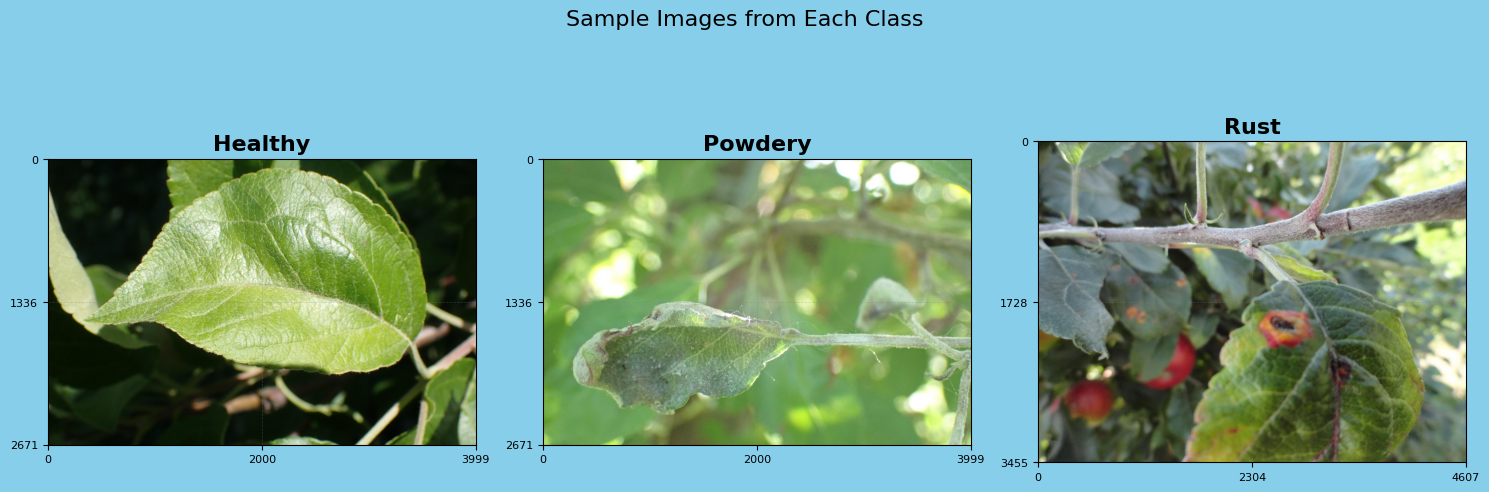

In [26]:
show_sample_images(trainpth, ['Healthy', 'Powdery', 'Rust'])

## Training Sample Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-92.89155..139.8458].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-108.54919..151.03052].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-83.72439..135.02103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-103.939..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-103.84609..151.061].


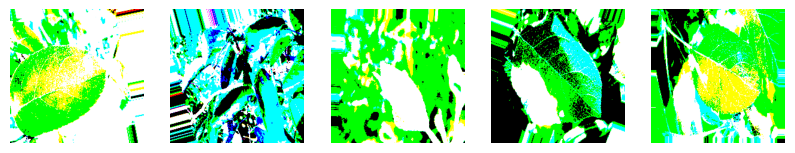

In [9]:
images, labels = next(train_gen_vgg)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()


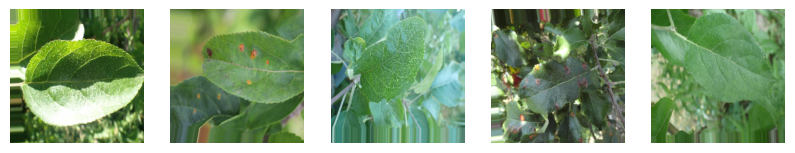

In [10]:
images, labels = next(train_gen_scratch)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [11]:
EPOCHS = 26

## CNN Model

In [12]:
# ----- Small custom CNN from scratch -----
model_scratch = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    # Conv block 1
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Conv block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model_scratch.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

# ----- Train -----
history_scratch = model_scratch.fit(
    train_gen_scratch,
    epochs=EPOCHS,
    validation_data=val_gen_scratch
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,427,875 (24.52 MB)

 Trainable params: 6,427,875 (24.52 MB)

 Non-trainable params: 0 (0.00 B)

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 161s 4s/step - accuracy: 0.3631 - loss: 1.3279 - val_accuracy: 0.3500 - val_loss: 1.0519
Epoch 2/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.4796 - loss: 0.9657 - val_accuracy: 0.5000 - val_loss: 0.9091
Epoch 3/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.6301 - loss: 0.8281 - val_accuracy: 0.6833 - val_loss: 0.7686
Epoch 4/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.6241 - loss: 0.7581 - val_accuracy: 0.7500 - val_loss: 0.6622
Epoch 5/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6649 - loss: 0.7180 - val_accuracy: 0.7667 - val_loss: 0.5649
Epoch 6/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.7194 - loss: 0.6429 - val_accuracy: 0.7500 - val_loss: 0.6127
Epoch 7/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.7035 - loss: 0.6916 - val_accuracy: 0.7500 - val_loss: 0.5728
Epoch 8/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.7610 - loss: 0.5716 - val_accuracy: 0.8167 - v

## VGG16 Model

In [13]:
# Transfer Learning Model
# ----- VGG16 base model -----
base_model = VGG16(
    weights='imagenet',
    include_top=False,         
    input_shape=(224, 224, 3)
)

# Freeze convolutional base
base_model.trainable = False

# ----- Add custom classifier head -----
inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model_vgg = models.Model(inputs, outputs)

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
# ----- Train -----
history_vgg = model_vgg.fit(
    train_gen_vgg,
    epochs=EPOCHS,
    validation_data=val_gen_vgg
)



Epoch 1/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.3835 - loss: 2.9954 - val_accuracy: 0.6833 - val_loss: 0.8929
Epoch 2/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.5613 - loss: 1.7740 - val_accuracy: 0.8500 - val_loss: 0.3891
Epoch 3/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.6838 - loss: 1.0834 - val_accuracy: 0.9167 - val_loss: 0.2731
Epoch 4/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.7625 - loss: 0.7699 - val_accuracy: 0.9000 - val_loss: 0.2605
Epoch 5/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.7708 - loss: 0.7694 - val_accuracy: 0.9167 - val_loss: 0.1817
Epoch 6/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.8253 - loss: 0.5558 - val_accuracy: 0.9167 - val_loss: 0.1938
Epoch 7/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.8336 - loss: 0.4928 - val_accuracy: 0.9167 - val_loss: 0.1624
Epoch 8/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.8502 - loss: 0.4278 - val_accuracy: 0.9500 - v

In [ ]:

# ----- Optional: fine-tune last few layers -----
base_model.trainable = True
for layer in base_model.layers[:-4]:   # keep all but last 4 layers frozen
    layer.trainable = False

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_fine = model_vgg.fit(
    train_gen_vgg,
    epochs=5,
    validation_data=val_gen_vgg
)

In [15]:
# Save the trained model
model_vgg.save("vgg16_transfer_learning.keras")

# Save the scratch model
model_scratch.save("scratch_cnn.keras")

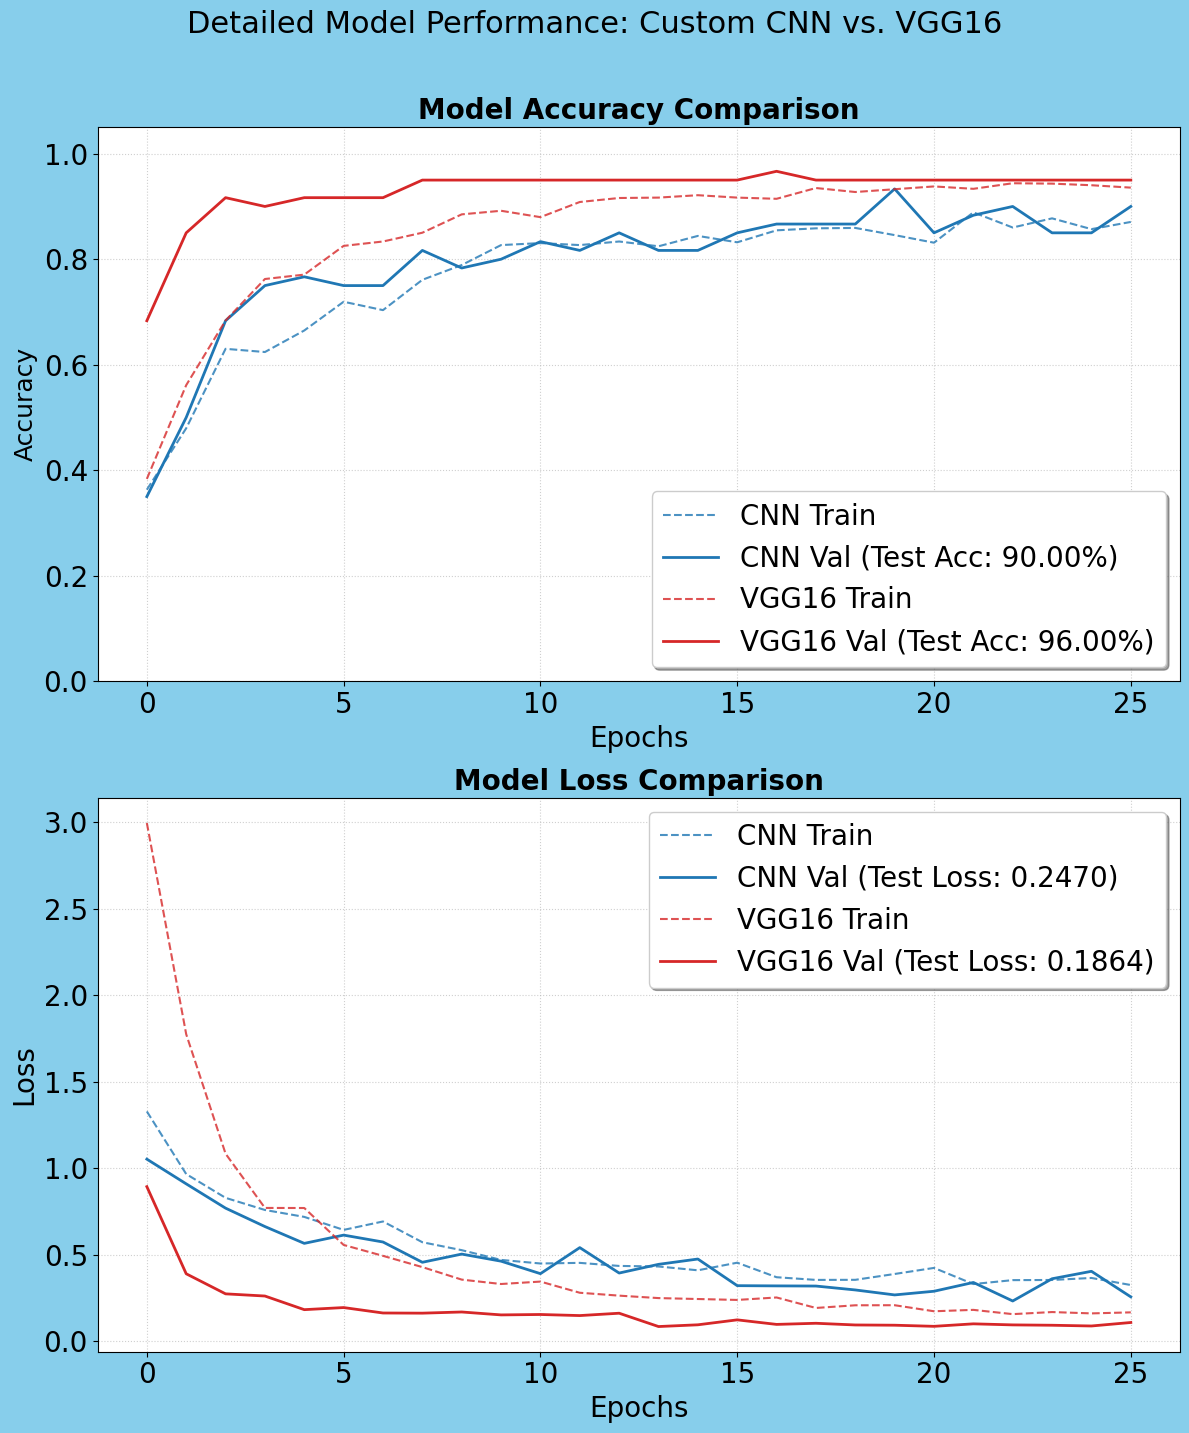

In [32]:
def plot_comparison_stacked(histories, titles, test_metrics):
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), facecolor = 'skyblue')
    colors = ['#1f77b4', '#1f77b4', '#d62728', '#d62728'] 

    for i, (history, name, metrics) in enumerate(zip(histories, titles, test_metrics)):
        test_loss, test_acc = metrics
        
        # --- Plot Accuracy (Top Subplot) ---
        ax1.plot(history.history['accuracy'], label=f'{name} Train', 
                 linestyle='--', color=colors[i*2], alpha=0.8)
        # We attach the Test Accuracy info to the Validation label
        ax1.plot(history.history['val_accuracy'], 
                 label=f'{name} Val (Test Acc: {test_acc:.2%})', 
                 linewidth=2, color=colors[i*2+1])
        
        # --- Plot Loss (Bottom Subplot) ---
        ax2.plot(history.history['loss'], label=f'{name} Train', 
                 linestyle='--', color=colors[i*2], alpha=0.8)
        # We attach the Test Loss info to the Validation label
        ax2.plot(history.history['val_loss'], 
                 label=f'{name} Val (Test Loss: {test_loss:.4f})', 
                 linewidth=2, color=colors[i*2+1])

    # Styling Accuracy Plot (ax1)
    ax1.set_title('Model Accuracy Comparison', fontsize=20, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=18)
    ax1.set_ylim(0, 1.05) # Accuracy is usually 0-1

    # Styling Loss Plot (ax2)
    ax2.set_title('Model Loss Comparison', fontsize=20, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=20)

    # General styling for both
    for ax in [ax1, ax2]:
        ax.set_xlabel('Epochs', fontsize=20)
        ax.grid(True, linestyle=':', alpha=0.6)

        ax.tick_params(axis='both', which='major', labelsize=20)
        
        # Position legend outside or in the best spot
        ax.legend(loc='best', frameon=True, shadow=True, fontsize=20)

    plt.suptitle("Detailed Model Performance: Custom CNN vs. VGG16", fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN ---

# 1. Get metrics
test_metrics_scratch = model_scratch.evaluate(test_gen_scratch, verbose=0)
test_metrics_vgg = model_vgg.evaluate(test_gen_vgg, verbose=0)

# 2. Run the stacked plotter
plot_comparison_stacked(
    [history_scratch, history_vgg], 
    ['CNN', 'VGG16'], 
    [test_metrics_scratch, test_metrics_vgg]
)

## Confusion Matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step


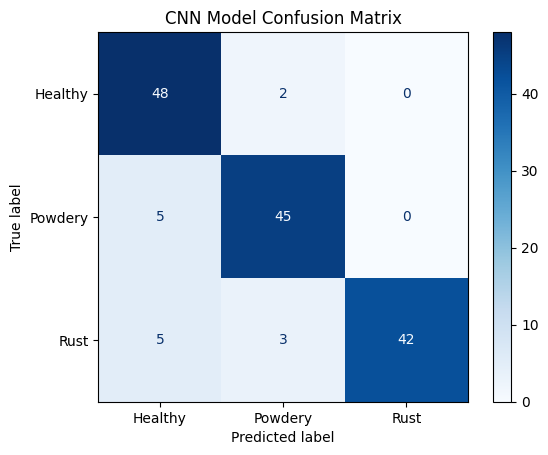

5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step


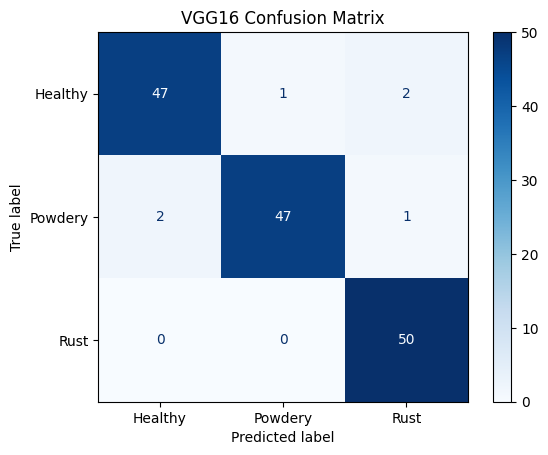

In [17]:
def plot_confusion_matrix(model, generator, title):
    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=generator.class_indices.keys()
    )
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

plot_confusion_matrix(model_scratch, test_gen_scratch, "CNN Model Confusion Matrix")
plot_confusion_matrix(model_vgg, test_gen_vgg, "VGG16 Confusion Matrix")

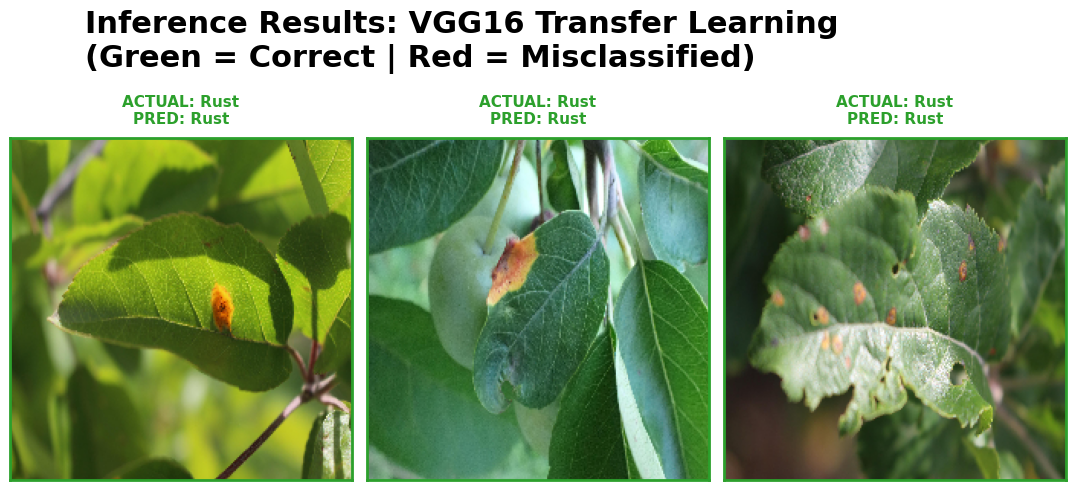

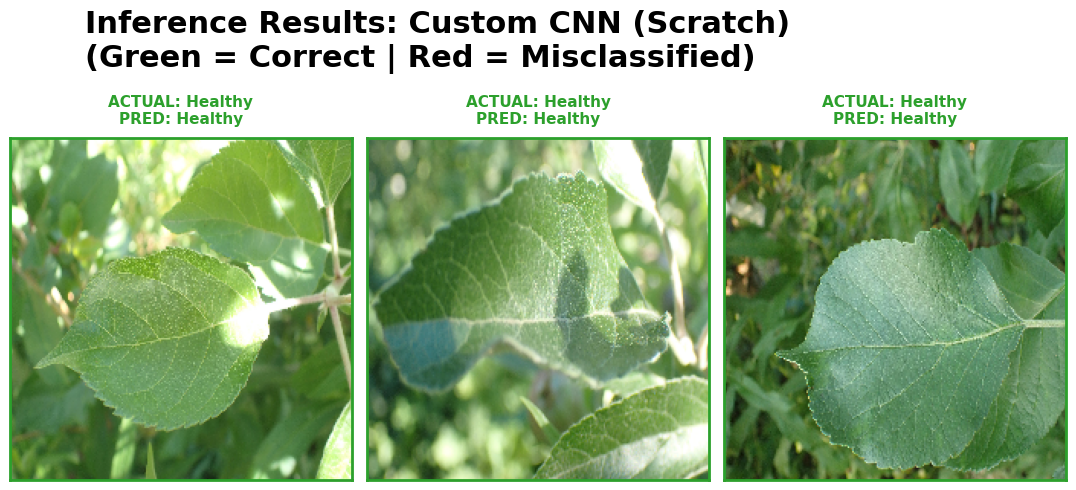

In [31]:
def plot_random_predictions(model, generator, model_name="Model", num_samples=3):
    # 1. Pick a random batch index
    num_batches = len(generator)
    random_batch_idx = np.random.randint(0, num_batches)
    
    # 2. Get that specific batch
    images, labels = generator[random_batch_idx]
    
    # 3. Get predictions for this batch
    predictions = model.predict(images, verbose=0)
    
    # 4. Convert to class names
    pred_indices = np.argmax(predictions, axis=1)
    true_indices = np.argmax(labels, axis=1)
    idx_to_class = {v: k for k, v in generator.class_indices.items()}
    
    # 5. Determine grid size
    num_to_show = min(num_samples, len(images))
    cols = 5
    rows = (num_to_show + cols - 1) // cols
    
    # 6. Pick random indices
    sample_indices = np.random.choice(range(len(images)), num_to_show, replace=False)
    
    plt.figure(figsize=(18, 5 * rows))
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(rows, cols, i + 1, facecolor = 'skyblue')
        
        img = images[idx].copy()
        
        # --- SMART DEPROCESSING ---
        if img.min() < 0: 
            # Case A: VGG Preprocessing (Mean subtraction)
            img[:, :, 0] += 103.939
            img[:, :, 1] += 116.779
            img[:, :, 2] += 123.68
            img = img[:, :, ::-1] # BGR to RGB
        elif img.max() <= 1.0:
            # Case B: Standard Rescaling (0-1)
            # Multiply by 255 so we can use uint8 safely
            img = img * 255.0
            
        img = np.clip(img, 0, 255).astype('uint8')
        
        plt.imshow(img)
        
        # Labels and Logic
        actual_name = idx_to_class[true_indices[idx]]
        pred_name = idx_to_class[pred_indices[idx]]
        is_correct = actual_name == pred_name
        title_color = '#2ca02c' if is_correct else '#d62728'
        
        plt.title(f"ACTUAL: {actual_name}\nPRED: {pred_name}", 
                  color=title_color, fontsize=11, fontweight='bold', pad=10)
        
        # Visual styling for borders
        for spine in plt.gca().spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(title_color)
            spine.set_linewidth(2)
            
        plt.xticks([]); plt.yticks([])

    plt.suptitle(f"Inference Results: {model_name}\n(Green = Correct | Red = Misclassified)", 
                 fontsize=22, fontweight='bold', x=0.05, y=1.02, ha='left')
    
    plt.tight_layout()
    plt.show()
    
# Pass the model name as a string to make the title dynamic
plot_random_predictions(model_vgg, test_gen_vgg, model_name="VGG16 Transfer Learning", num_samples=3)
plot_random_predictions(model_scratch, test_gen_scratch, model_name="Custom CNN (Scratch)", num_samples=3)